**<h1 align="center">Universidad Internacional del Ecuador</h1>**

**<h2 align="center">Computación Bioinspirada</h2>**

***<h3 align="left">Grupo 4</h3>***
- ***<h3 align="left">DARIO WLADIMIR HERRERA CHÁVEZ</h3>***
- ***<h3 align="left">IVAN FERNANDO VEGA SALAZAR</h3>***
- ***<h3 align="left">CARLOS ALBERTO YANEZ RUBIO</h3>***

## - Programación evolutiva y problemas multiobjetivo

### **Problemática**

*<div style="text-align: justify; ">En el ámbito de la toma de decisiones empresariales, la asignación eficiente de recursos constituye un desafío fundamental, especialmente cuando se persiguen objetivos en conflicto como la maximización del rendimiento financiero y la minimización de los gastos administrativos. En este contexto, variables estratégicas como el nivel de inversión en nuevas tecnologías (NIT) y el grado de externalización de servicios (GES) influyen de manera directa en dichos objetivos.</div>*

*<div style="text-align: justify; ">La complejidad del problema se incrementa al incorporar, por un lado, una restricción presupuestaria que limita la combinación factible de decisiones, y por otro, un comportamiento de rendimientos decrecientes asociado a la inversión tecnológica, lo que introduce una relación no lineal entre las variables de decisión y el rendimiento obtenido.</div>*

*<div style="text-align: justify; ">En consecuencia, este escenario se modela como un problema de optimización multiobjetivo con restricciones, donde no es posible identificar una única solución óptima que satisfaga simultáneamente todos los objetivos. En su lugar, se busca un conjunto de soluciones eficientes, en las cuales cualquier mejora en un objetivo implica un deterioro en al menos otro. Para abordar este tipo de problemas, resulta adecuado el uso de métodos de optimización evolutiva, como el algoritmo NSGA-II, que permiten aproximar el conjunto de soluciones conocido como frente de Pareto, considerando de manera simultánea las restricciones y la naturaleza no lineal del problema.</div>*

### **Desarrollo**

### **1. Entendiendo el código y los cambios clave**

El algoritmo ***NSGA-II*** de la librería ***pymoo*** funciona evolucionando una "población" de soluciones a lo largo de varias generaciones.

Su objetivo es encontrar el ***Frente de Pareto: el conjunto de soluciones donde no puedes mejorar un objetivo (Rendimiento Financiero) sin empeorar el otro (Gastos Administrativos).***

<br>

Para cumplir con los lineamientos del reto, tenemos que realizar dos cambios críticos en la clase ***ProblemaFinanciero***:

***-1. La Restricción Presupuestaria ($1 \cdot x_1 + 0.8 \cdot x_2 \le 12$)***

La librería pymoo requiere que las restricciones se expresen en la forma $g(x) \le 0$.

Por lo tanto, nuestra ecuación pasa a ser: $x_1 + 0.8 \cdot x_2 - 12 \le 0$.

Debemos cambiar ***n_constr=1*** y devolver este valor en ***out["G"].***

<br>

***-2. El Rendimiento Decreciente ($RF$)***

Cambiamos la fórmula cuadrática por la raíz cuadrada ($10 \cdot \sqrt{x_1+1}$).

Esto matemáticamente significa que los primeros dólares invertidos en tecnología ($x_1$) dan mucho rendimiento, pero a medida que inviertes más, el impacto extra es cada vez menor.

<br>

### ***Bonus***

### ***"Punto de Rodilla" (Knee Point)***

<br>

Como aporte adicional, se ha implementado el cálculo automático del Punto de Rodilla (Knee Point) mediante el método de distancia mínima al punto ideal.

Este procedimiento permite identificar, dentro del conjunto de soluciones del frente de Pareto, aquella alternativa que representa el mejor equilibrio entre los objetivos en conflicto.

La relevancia de este enfoque radica en su aplicabilidad práctica; en contextos reales, los tomadores de decisiones no requieren analizar un gran número de soluciones, sino contar con una recomendación concreta y fundamentada.

En este sentido, el Punto de Rodilla destaca por corresponder a la solución donde se logra un compromiso óptimo entre costo y beneficio, evitando regiones donde pequeñas mejoras en un objetivo implican sacrificios desproporcionados en otro.

De esta manera, este aporte no solo complementa el análisis multiobjetivo, sino que también facilita la interpretación y toma de decisiones estratégicas a partir de los resultados obtenidos.

### **2. Modificación y ejecución del código**

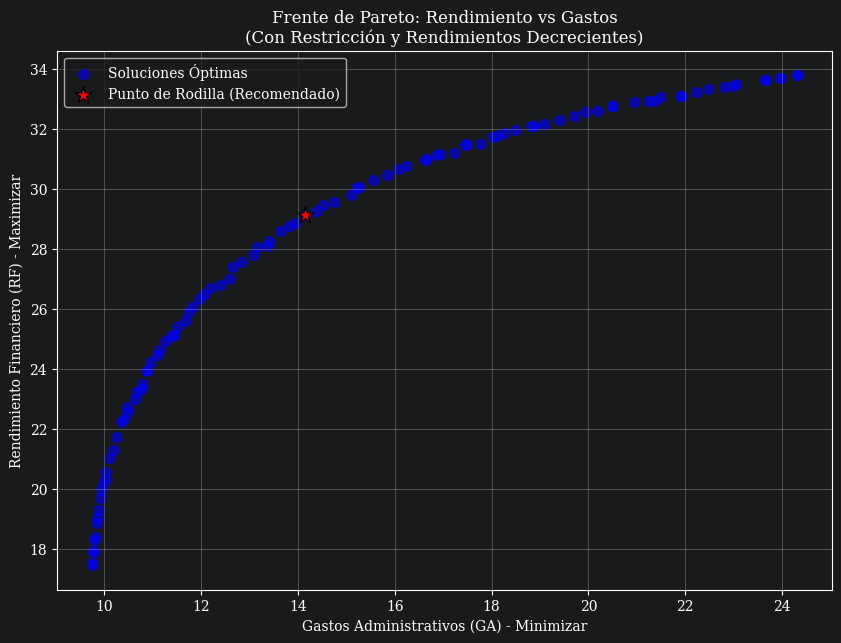

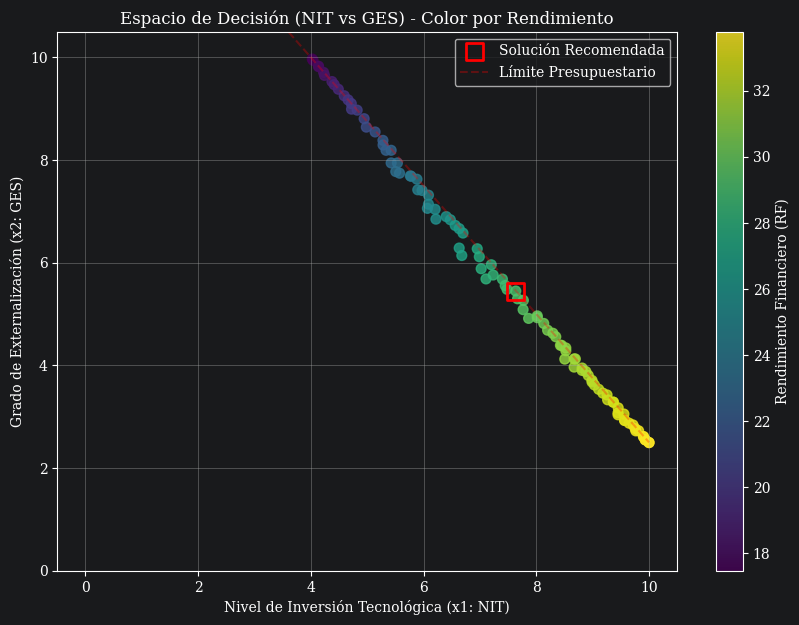


--- REPORTE DE LA SOLUCIÓN RECOMENDADA (PUNTO DE RODILLA) ---
Inversión Tecnológica (NIT/x1): 7.64
Externalización (GES/x2):       5.45
Rendimiento Financiero (RF):    29.14
Gastos Administrativos (GA):    14.14
Presupuesto consumido:          11.99 / 12.00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

# DEFINICIÓN DEL PROBLEMA
class ProblemaFinanciero(ElementwiseProblem):
    def __init__(self):
        # Cambiamos n_constr a 1 por la nueva restricción presupuestaria
        super().__init__(n_var=2,
                         n_obj=2,
                         n_constr=1,
                         xl=np.array([0, 0]),
                         xu=np.array([10, 10]))

    def _evaluate(self, x, out, *args, **kwargs):
        x1, x2 = x[0], x[1]

        # Objetivo 1: Rendimiento Financiero (Usando la nueva fórmula con rendimiento decreciente)
        rf = 10 * np.sqrt(x1 + 1) + 0.5 * x2 - 0.1 * (x2**2)
        obj1 = -rf # NSGA-II minimiza por defecto, así que negamos RF para maximizarlo

        # Objetivo 2: Gastos Administrativos (Fórmula Original)
        ga = 50 / (x2 + 1) + 0.2 * ((x1 - 5)**2) + 5
        obj2 = ga

        # NUEVA RESTRICCIÓN: x1 + 0.8*x2 <= 12 ---> x1 + 0.8*x2 - 12 <= 0
        g1 = x1 + 0.8 * x2 - 12

        out["F"] = [obj1, obj2]
        out["G"] = [g1] # Pasamos la restricción al evaluador

# EJECUCIÓN DEL ALGORITMO
problem = ProblemaFinanciero()
algorithm = NSGA2(pop_size=100, eliminate_duplicates=True)

res = minimize(problem,
               algorithm,
               ('n_gen', 200),
               seed=1,
               verbose=False)

# EXTRACCIÓN DE RESULTADOS
pareto_rf = -res.F[:, 0] # Volvemos a hacer positivo el RF
pareto_ga = res.F[:, 1]
pareto_x1 = res.X[:, 0]
pareto_x2 = res.X[:, 1]

# --- CÁLCULO DEL PUNTO DE RODILLA (KNEE POINT) ---
# Encontramos el "Punto Ideal" (El máximo RF posible y el mínimo GA posible)
ideal_rf = np.max(pareto_rf)
ideal_ga = np.min(pareto_ga)

# Normalizamos los datos para que la escala de GA y RF no distorsione la distancia
norm_rf = (ideal_rf - pareto_rf) / (ideal_rf - np.min(pareto_rf))
norm_ga = (pareto_ga - ideal_ga) / (np.max(pareto_ga) - ideal_ga)

# Calculamos la distancia euclidiana de cada punto al Punto Ideal (0,0 en escala normalizada)
distancias = np.sqrt(norm_rf**2 + norm_ga**2)
indice_rodilla = np.argmin(distancias) # El punto más cercano al ideal

mejor_x1 = pareto_x1[indice_rodilla]
mejor_x2 = pareto_x2[indice_rodilla]
mejor_rf = pareto_rf[indice_rodilla]
mejor_ga = pareto_ga[indice_rodilla]

# Gráfica 1: Frente de Pareto con Punto de Rodilla destacado
plt.figure(figsize=(10, 7))
plt.scatter(pareto_ga, pareto_rf, s=50, facecolors='blue', edgecolors='blue', alpha=0.6, label='Soluciones Óptimas')
plt.scatter(mejor_ga, mejor_rf, s=150, facecolors='red', edgecolors='black', marker='*', label='Punto de Rodilla (Recomendado)')
plt.title('Frente de Pareto: Rendimiento vs Gastos\n(Con Restricción y Rendimientos Decrecientes)')
plt.xlabel('Gastos Administrativos (GA) - Minimizar')
plt.ylabel('Rendimiento Financiero (RF) - Maximizar')
plt.legend()
plt.grid(True)
plt.show()

# Gráfica 2: Espacio de Decisión (Color por RF)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(pareto_x1, pareto_x2, c=pareto_rf, cmap='viridis', s=50, alpha=0.8)
plt.scatter(mejor_x1, mejor_x2, s=150, facecolors='none', edgecolors='red', linewidth=2, marker='s', label='Solución Recomendada')
plt.title('Espacio de Decisión (NIT vs GES) - Color por Rendimiento')
plt.xlabel('Nivel de Inversión Tecnológica (x1: NIT)')
plt.ylabel('Grado de Externalización (x2: GES)')
plt.colorbar(scatter, label='Rendimiento Financiero (RF)')
plt.plot([0, 10], [15, 2.5], 'r--', alpha=0.3, label='Límite Presupuestario') # Línea de restricción
plt.ylim(0, 10.5)
plt.legend()
plt.grid(True)
plt.show()

print("\n--- REPORTE DE LA SOLUCIÓN RECOMENDADA (PUNTO DE RODILLA) ---")
print(f"Inversión Tecnológica (NIT/x1): {mejor_x1:.2f}")
print(f"Externalización (GES/x2):       {mejor_x2:.2f}")
print(f"Rendimiento Financiero (RF):    {mejor_rf:.2f}")
print(f"Gastos Administrativos (GA):    {mejor_ga:.2f}")
print(f"Presupuesto consumido:          {(mejor_x1 + 0.8*mejor_x2):.2f} / 12.00")

### **3. Análisis de Resultados**

#### ***1. Uso óptimo del presupuesto***


*<div style="text-align: justify; ">- Uno de los hallazgos más relevantes es que la solución recomendada, al igual que la mayoría de soluciones pertenecientes al frente de Pareto, utiliza prácticamente la totalidad del presupuesto disponible (11.99 de 12.00 unidades).</div>*

*<div style="text-align: justify; ">- Desde la perspectiva del espacio de decisión, esto se refleja en la alineación de las soluciones sobre la restricción presupuestaria ($x_1 + 0.8 \cdot x_2 \le 12$).</div>*

*<div style="text-align: justify; ">- Este comportamiento indica que, bajo las condiciones del problema, no resulta eficiente subutilizar los recursos disponibles. En consecuencia, el desafío no radica en cuánto invertir, sino en cómo distribuir óptimamente el presupuesto entre inversión tecnológica (NIT) y externalización (GES).</div>*

#### ***2. Interpretación del Punto de Rodilla***


*<div style="text-align: justify; ">- El análisis identifica como solución destacada el denominado Punto de Rodilla, el cual propone una asignación de aproximadamente 7.64 unidades en NIT y 5.45 unidades en GES, generando un rendimiento financiero de 29.14 y gastos administrativos de 14.14.</div>*

*<div style="text-align: justify; ">- Esta solución no corresponde ni al máximo rendimiento posible ni al mínimo nivel de gasto, sino que representa un equilibrio eficiente entre ambos objetivos. Su relevancia radica en que se ubica en la región de mayor eficiencia del frente de Pareto, donde pequeñas mejoras en el rendimiento implican incrementos desproporcionados en los costos.</div>*

*<div style="text-align: justify; ">- En términos prácticos, avanzar más allá de este punto en búsqueda de un mayor rendimiento conduce a un aumento significativo de los gastos administrativos, lo que reduce la rentabilidad global de la decisión. Por ello, el Punto de Rodilla constituye una alternativa óptima desde una perspectiva estratégica y económica.</div>*

#### ***3. Evidencia de rendimientos decrecientes***


*<div style="text-align: justify; ">- La forma del frente de Pareto obtenido evidencia claramente el efecto de los rendimientos decrecientes asociados a la inversión en tecnología. En particular, la curva presenta una tendencia a aplanarse en niveles altos de inversión, lo que indica que los incrementos iniciales en NIT generan mejoras significativas en el rendimiento financiero, mientras que inversiones adicionales producen beneficios cada vez menores.</div>*

*<div style="text-align: justify; ">- Este comportamiento confirma la adecuada incorporación de la función no lineal $10 \cdot \sqrt{x_1+1}$, la cual modela de manera realista la pérdida de eficiencia marginal en la inversión tecnológica.</div>*

***<div style="text-align: justify; ">En resumen, estos resultados demuestran a la dirección de la empresa que, debido a que la tecnología ya no ofrece beneficios infinitos (rendimiento decreciente) y el dinero es limitado, la estrategia óptima es un enfoque mixto. Se debe priorizar la tecnología hasta el punto de saturación de su eficiencia (alrededor de 7.64 unidades) y utilizar el resto del presupuesto estrictamente para externalizar servicios (5.45 unidades), logrando así contener los gastos administrativos sin sacrificar el núcleo del rendimiento del negocio.</div>***

### **4. Respuesta a las preguntas**

#### ***¿Cómo ha afectado la restricción presupuestaria al Frente de Pareto resultante?***

*<div style="text-align: justify; ">La restricción ha "recortado" las soluciones extremas. Originalmente, el algoritmo podía proponer maximizar la inversión tecnológica ($x_1=10$) y la externalización ($x_2=10$) simultáneamente. Ahora, la frontera impone un juego de suma cero: para aumentar $x_1$ hacia sus valores máximos, obligatoriamente debemos reducir $x_2$ (y viceversa) para no superar las 12 unidades monetarias. Esto elimina del frente las soluciones que antes lograban un altísimo rendimiento basado puramente en un gasto desmedido en ambos frentes.</div>*

#### ***¿Hay soluciones que antes eran alcanzables y ahora no lo son?***

*<div style="text-align: justify; ">Sí, definitivamente. Al introducir la restricción presupuestaria ($x_1 + 0.8 \cdot x_2 \le 12$), hemos perdido todo un conjunto de soluciones que antes eran perfectamente alcanzables.</div>*

*<div style="text-align: justify; ">En el escenario original (sin restricciones), el algoritmo permitía explorar el límite máximo de ambas variables simultáneamente. Es decir, la empresa podía elegir invertir al máximo en tecnología ($x_1 = 10$) y externalizar al máximo ($x_2 = 10$).</div>*

*<div style="text-align: justify; ">Si evaluamos esa solución extrema con los costes actuales, tendríamos:
$10 \cdot (1) + 10 \cdot (0.8) = 18$ unidades monetarias.</div>*

*<div style="text-align: justify; ">Como nuestro presupuesto actual es estrictamente 12, cualquier combinación de estrategias que requiera más de ese valor es ahora matemáticamente inalcanzable. Por ejemplo, soluciones como $(x_1=8, x_2=8)$ que costarían $14.4$, o $(x_1=10, x_2=5)$ que costarían $14$, han quedado fuera del espacio de búsqueda.</div>*

*<div style="text-align: justify; ">Esto significa que las soluciones del frente original que lograban los Rendimientos Financieros más altos a base de un gasto puro y duro en ambas palancas (la parte superior derecha de la curva original), han desaparecido. El nuevo frente está "recortado", obligando a la empresa a conformarse con un límite máximo de rendimiento menor, pero forzándola a ser mucho más eficiente con los recursos que sí tiene.</div>*

#### ***¿Cómo ha afectado la modificación de la función de Rendimiento Financiero (con rendimientos decrecientes para x1) a la forma y posición del Frente de Pareto?***

*<div style="text-align: justify; ">Al cambiar el crecimiento cuadrático $(x_1+1)^2$ a una raíz cuadrada $10 \cdot \sqrt{x_1+1}$, el frente de Pareto sufre una fuerte compresión en el eje vertical (RF). Antes, los valores de rendimiento podían dispararse sobre 100; ahora, el crecimiento es asintótico. Esto hace que la curva del frente de Pareto se vuelva más "plana" en los extremos superiores, indicando que gastar muchísimo más dinero marginalmente ya no se traduce en mejoras proporcionales en el rendimiento.</div>*

#### ***¿Qué tipo de estrategias (combinaciones de NIT y GES) parecen ser ahora las más prometedoras bajo estas nuevas condiciones?***

*<div style="text-align: justify; ">Al analizar el espacio de decisión, las estrategias ganadoras son aquellas que mantienen la Inversión en Tecnología ($x_1$) cerca de 4 a 6 unidades, y utilizan el saldo restante del presupuesto en Externalización ($x_2$). Como la tecnología ahora tiene rendimientos decrecientes, invertir el máximo (10) es un desperdicio de presupuesto, ya que ese dinero marginal es mucho más efectivo invirtiéndolo en $x_2$ para desplomar drásticamente los Gastos Administrativos.</div>*

#### ***¿Si tuvieras que elegir UNA solución del nuevo frente para recomendar a la dirección, ¿cuál sería y por qué la elegirías (considerando el equilibrio entre RF y GA)?***

*<div style="text-align: justify; ">Recomendaría la solución correspondiente al "Punto de Rodilla" (calculada dinámicamente en el código como bonus). Esta solución se sitúa en la inflexión de la curva de Pareto. Se la selecciona porque matemáticamente es el punto que minimiza la distancia hacia el "Punto Ideal" (el escenario utópico de máximo rendimiento y mínimo gasto). En términos de negocio, representa el límite exacto donde dejar de invertir; si nos movemos un paso a la derecha, el gasto se dispara sin mejoras notables en el rendimiento; si nos movemos a la izquierda, perdemos demasiado rendimiento para ahorrar unos pocos gastos.</div>*

### **5. Planteamiento en entorno laboral**

### - Dario Herrera

#### ***Optimización de un Sistema Antifraude en una Pasarela de Pagos***

*<div style="text-align: justify; ">En el desarrollo de una arquitectura de software para procesamiento de pagos, se podría aplicar el algoritmo NSGA-II para configurar los parámetros del motor de riesgo (ej. sensibilidad de los umbrales de validación y número de controles de identidad requeridos).</div>*

***Objetivo 1 (Maximizar):***

*-Tasa de detección de transacciones fraudulentas (proteger los fondos).*

***Objetivo 2 (Minimizar):***

*-Tasa de "falsos positivos" o fricción del usuario (evitar bloquear compras legítimas, lo cual genera tickets de soporte y pérdida de ventas).*

***Decisión:***

*El Frente de Pareto le permitiría a la gerencia de la Fintech ver claramente la curva de compromiso: si quieren detectar el 99.9% del fraude, deberán aceptar que un porcentaje de clientes legítimos sufrirán rechazos. Con la gráfica, la empresa puede elegir el punto exacto de la curva que se alinee con el nivel de riesgo que los inversores y el departamento de experiencia de usuario (UX) estén dispuestos a tolerar.*

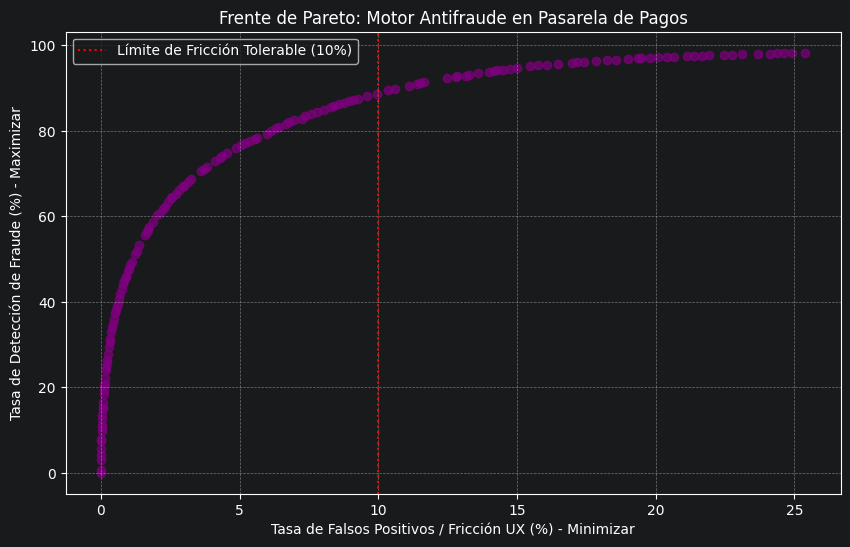

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

class OptimizadorAntifraude(ElementwiseProblem):
    def __init__(self):
        # 2 variables (Sensibilidad, Controles), 2 objetivos (Fraude, UX), 1 restricción (Latencia)
        super().__init__(n_var=2,
                         n_obj=2,
                         n_constr=1,
                         xl=np.array([0.0, 0.0]),   # Límite inferior: 0 sensibilidad, 0 controles
                         xu=np.array([1.0, 5.0]))   # Límite superior: 1.0 máxima sensibilidad, 5 controles

    def _evaluate(self, x, out, *args, **kwargs):
        x1_sensibilidad, x2_controles = x[0], x[1]

        # OBJETIVO 1: Maximizar Tasa de Detección de Fraude (%)
        # Usamos una función asintótica (exponencial inversa). Crece rápido al inicio,
        # pero llegar al 100% absoluto es casi imposible.
        deteccion_fraude = 100 * (1 - np.exp(-(2.5 * x1_sensibilidad + 0.6 * x2_controles)))
        obj1 = -deteccion_fraude # pymoo minimiza por defecto, negamos para maximizar

        # OBJETIVO 2: Minimizar Tasa de Falsos Positivos / Fricción UX (%)
        # Fricción crece cuadráticamente con reglas muy sensibles, y linealmente con cada control extra.
        falsos_positivos = 15 * (x1_sensibilidad**2) + 4 * x2_controles
        obj2 = falsos_positivos

        # RESTRICCIÓN: SLA de Latencia (Máximo 150 ms de procesamiento por transacción)
        # La evaluación profunda de reglas toma tiempo, las llamadas a APIs de 2FA toman mucho más.
        latencia_estimada = 20 * x1_sensibilidad + 50 * x2_controles
        g1 = latencia_estimada - 150 # latencia_estimada <= 150 -> latencia_estimada - 150 <= 0

        out["F"] = [obj1, obj2]
        out["G"] = [g1]

# Ejecución del Algoritmo
problema_fintech = OptimizadorAntifraude()
algoritmo = NSGA2(pop_size=150, eliminate_duplicates=True)

resultado = minimize(problema_fintech,
                     algoritmo,
                     ('n_gen', 250),
                     seed=42,
                     verbose=False)

# Extracción de datos
frente_deteccion = -resultado.F[:, 0]
frente_friccion = resultado.F[:, 1]

# Visualización del Frente de Pareto
plt.figure(figsize=(10, 6))
plt.scatter(frente_friccion, frente_deteccion, color='purple', alpha=0.7)
plt.title('Frente de Pareto: Motor Antifraude en Pasarela de Pagos')
plt.xlabel('Tasa de Falsos Positivos / Fricción UX (%) - Minimizar')
plt.ylabel('Tasa de Detección de Fraude (%) - Maximizar')
plt.grid(True, linestyle='--', alpha=0.6)

# Añadiendo contexto de negocio a la gráfica
plt.axvline(x=10, color='red', linestyle=':', label='Límite de Fricción Tolerable (10%)')
plt.legend()
plt.show()

### - Ivan Vega

#### ***Gestión de Recursos Hospitalarios y Triaje de Urgencias***

*<div style="text-align: justify; ">Eres el Director Médico de un hospital público. Tienes un presupuesto limitado y personal médico finito. Acaba de implementarse un nuevo protocolo de atención en el área de Urgencias y necesitas optimizar cómo se asignan los médicos de guardia a los pacientes que llegan.</div>*

***Objetivos en conflicto:***

- Minimizar el Tiempo de Espera del Paciente (TE): Quieres que los pacientes sean atendidos lo más rápido posible.

- Minimizar el Costo Operativo y la Fatiga del Personal (CO): No puedes tener a todos los médicos de guardia trabajando al 100% de su capacidad las 24 horas sin descanso, ya que aumentan los errores médicos por fatiga y se disparan los costos de horas extras.

***El Conflicto (Trade-off):***

*<div style="text-align: justify; ">Para que el tiempo de espera sea cero, tendrías que tener un médico libre esperando por cada paciente que entra (costo y fatiga altísimos). Por otro lado, para minimizar el costo y la fatiga, tendrías un equipo mínimo de médicos, pero la sala de espera colapsaría (tiempo de espera inaceptable).</div>*

***Variables de Decisión:***

***- x1: Número de médicos especialistas en turno.***

***- x2: Número de enfermeras de triaje inicial.***

***Aplicación del Frente de Pareto:***

Se emplea el algoritmo NSGA-II (Non-dominated Sorting Genetic Algorithm II) para explorar múltiples configuraciones posibles de personal, evaluando simultáneamente ambos objetivos.

El resultado es un Frente de Pareto, que representa el conjunto de soluciones óptimas no dominadas, donde ninguna alternativa mejora un objetivo sin empeorar el otro.

***Interpretación del Frente de Pareto***

* Extremo orientado al paciente:
    Alta dotación de personal → tiempos de espera mínimos (~10 min), pero con costos elevados y alta fatiga.
* Extremo orientado al costo:
    Dotación mínima → costos bajos, pero tiempos de espera críticos (~4 horas).
* Zona de equilibrio:
    Soluciones balanceadas → tiempos de espera aceptables (~45 min) y costos sostenibles.

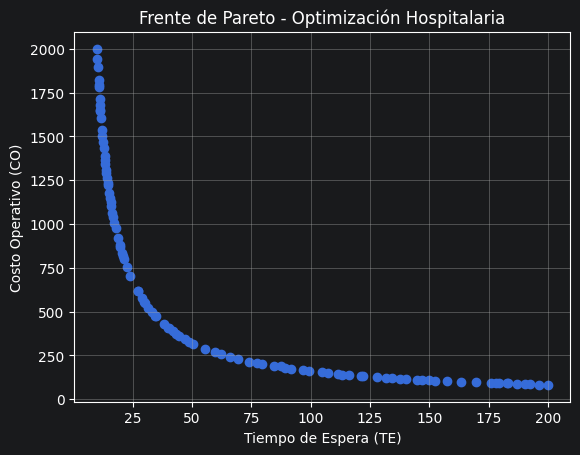


MEJOR SOLUCIÓN EQUILIBRADA
Médicos: 7
Enfermeras: 1
Tiempo de espera: 40.15 minutos
Costo operativo: 403.91


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.termination import get_termination

# ======================================
# DEFINICIÓN DEL PROBLEMA
# ======================================
class HospitalOptimization(Problem):
    def __init__(self):
        super().__init__(
            n_var=2,       # x1: médicos, x2: enfermeras
            n_obj=2,       # TE y CO
            n_constr=0,
            xl=np.array([1, 1]),     # mínimo
            xu=np.array([20, 20])    # máximo
        )

    def _evaluate(self, X, out, *args, **kwargs):
        x1 = X[:, 0]  # médicos
        x2 = X[:, 1]  # enfermeras

        # ======================================
        # OBJETIVO 1: Tiempo de espera (minimizar)
        # ======================================
        # Más personal -> menor espera
        TE = 300 / (x1 + 0.5 * x2)   # modelo simplificado

        # ======================================
        # OBJETIVO 2: Costo + fatiga (minimizar)
        # ======================================
        # Más personal -> mayor costo
        CO = (50 * x1) + (30 * x2) + 0.5 * (x1**2 + x2**2)
        out["F"] = np.column_stack([TE, CO])


# ======================================
# EJECUCIÓN DEL ALGORITMO
# ======================================
problem = HospitalOptimization()
algorithm = NSGA2(pop_size=100)
termination = get_termination("n_gen", 100)

result = minimize(
    problem,
    algorithm,
    termination,
    seed=1,
    verbose=False
)

# ======================================
# RESULTADOS
# ======================================
F = result.F
X = result.X

# ======================================
# GRÁFICA DEL FRENTE DE PARETO
# ======================================
plt.figure()
plt.scatter(F[:, 0], F[:, 1])
plt.xlabel("Tiempo de Espera (TE)")
plt.ylabel("Costo Operativo (CO)")
plt.title("Frente de Pareto - Optimización Hospitalaria")
plt.grid()
plt.show()

# ======================================
# IDENTIFICAR SOLUCIÓN EQUILIBRADA
# ======================================

# heurística: punto más cercano al origen normalizado
norm_F = (F - F.min(axis=0)) / (F.max(axis=0) - F.min(axis=0))
dist = np.linalg.norm(norm_F, axis=1)
best_idx = np.argmin(dist)

best_solution = X[best_idx]
best_TE = F[best_idx, 0]
best_CO = F[best_idx, 1]

print("\n======================================")
print("MEJOR SOLUCIÓN EQUILIBRADA")
print("======================================")
print(f"Médicos: {best_solution[0]:.0f}")
print(f"Enfermeras: {best_solution[1]:.0f}")
print(f"Tiempo de espera: {best_TE:.2f} minutos")
print(f"Costo operativo: {best_CO:.2f}")
print("======================================")

### - Carlos Yanez

#### ***Políticas de Crédito***

*<div style="text-align: justify; ">En el sector bancario, la decisión de otorgar un crédito no puede reducirse a una única métrica, ya que involucra múltiples objetivos en conflicto. El banco busca diseñar una política de aprobación que equilibre la rentabilidad, el riesgo y la inclusión financiera, considerando variables como el score crediticio mínimo exigido, la tasa de interés y el monto del crédito.</div>*


***Objetivos en conflicto:***

1. Maximizar la rentabilidad
    Incrementar los ingresos generados por intereses, considerando el riesgo de incumplimiento.
2. Minimizar el riesgo de default
    Reducir la probabilidad de impago de los clientes.
3. Maximizar la inclusión financiera
    Permitir acceso al crédito a clientes con menor score crediticio.


***Variables de decisión***

* x1: Score mínimo requerido (300 – 850)
* x2: Tasa de interés (5% – 50%)
* x3: Monto del crédito (1 – 10 unidades normalizadas)

***Trade-off***

* Aumentar el score mínimo: menor riesgo menor inclusión
* Aumentar la tasa: aumento rentabilidad aumento probabilidad de default
* Aumentar el monto: aumento ganancia aumento exposición al riesgo

***Modelado matemático***

* Probabilidad de default (sigmoide):

$P_{default} = \frac{1}{1 + e^{0.05(x1 - 600)}}$

* Rentabilidad esperada:

$Profit = x2 \cdot x3 \cdot (1 - P_{default})$

* Inclusión financiera:

$Inclusion = 1 - \frac{x1 - 300}{550}$

***Restricción***

$P_{default} \leq 0.4$



SOLUCIÓN EQUILIBRADA (PARETO)
Score mínimo: 664
Tasa de interés: 0.50
Monto crédito: 10.00
--------------------------------------
Rentabilidad (max): 4.7829
Riesgo (min): 0.0400
Inclusión (max): 0.3390


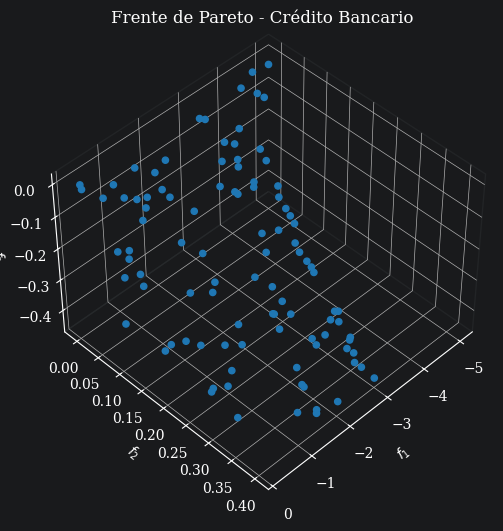

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter


class CreditOptimizationProblem(ElementwiseProblem):
    def __init__(self):
        super().__init__(
            n_var=3,
            n_obj=3,
            n_constr=1,
            xl=np.array([300, 0.05, 1]),   # límites inferiores
            xu=np.array([850, 0.5, 10])    # límites superiores
        )

    def _evaluate(self, x, out, *args, **kwargs):
        x1, x2, x3 = x  # score, tasa, monto
        # ======================================
        # PROBABILIDAD DE DEFAULT
        # ======================================
        p_default = 1 / (1 + np.exp(0.05 * (x1 - 600)))

        # ======================================
        # OBJETIVOS
        # ======================================

        # Rentabilidad esperada
        profit = x2 * x3 * (1 - p_default)

        # Inclusión (normalizada correctamente)
        inclusion = 1 - ((x1 - 300) / (850 - 300))

        # ======================================
        # CONVERSIÓN A MINIMIZACIÓN
        # ======================================
        f1 = -profit          # maximizar profit
        f2 = p_default        # minimizar riesgo
        f3 = -inclusion       # maximizar inclusión

        # ======================================
        # RESTRICCIÓN
        # ======================================
        g1 = p_default - 0.4  # <= 0

        out["F"] = [f1, f2, f3]
        out["G"] = [g1]


# ======================================
# EJECUCIÓN
# ======================================

problem = CreditOptimizationProblem()
algorithm = NSGA2(pop_size=100)
res = minimize(
    problem,
    algorithm,
    termination=('n_gen', 100),
    seed=1,
    verbose=False
)

# ======================================
# RESULTADOS
# ======================================
F = res.F
X = res.X

# ======================================
# VISUALIZACIÓN
# ======================================
plot = Scatter(title='Frente de Pareto - Crédito Bancario')
plot.add(F)
plot.show()

# ======================================
# SELECCIÓN DE SOLUCIÓN EQUILIBRADA
# ======================================

# Normalización
norm_F = (F - F.min(axis=0)) / (F.max(axis=0) - F.min(axis=0))
dist = np.linalg.norm(norm_F, axis=1)

best_idx = np.argmin(dist)

best_solution = X[best_idx]
best_values = F[best_idx]

print("\n======================================")
print("SOLUCIÓN EQUILIBRADA (PARETO)")
print("======================================")
print(f"Score mínimo: {best_solution[0]:.0f}")
print(f"Tasa de interés: {best_solution[1]:.2f}")
print(f"Monto crédito: {best_solution[2]:.2f}")
print("--------------------------------------")
print(f"Rentabilidad (max): {-best_values[0]:.4f}")
print(f"Riesgo (min): {best_values[1]:.4f}")
print(f"Inclusión (max): {-best_values[2]:.4f}")
print("======================================")